In [3]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(100)

In [4]:
def coordination_payoff(choice, neighbour_choice):
    if choice == neighbour_choice == 0: #stay
        return 1
    elif choice == neighbour_choice == 1: #defect
        return 2
    else: #non coorporate
        return 0
        

def coordination(neighbours):
    payoff_0 = sum(
        coordination_payoff(0, n.on)
        for n in neighbours
    )

    payoff_1 = sum(
        coordination_payoff(1, n.on)
        for n in neighbours
    )

    if payoff_1 > payoff_0:
        return 1
    else:
        return 0

def p_coordination(neighbours, repression, benefit):
    payoff_0 = sum(
        coordination_payoff(0, n.on)
        for n in neighbours
    )

    payoff_1 = sum(
        coordination_payoff(1, n.on)
        for n in neighbours
    )

    if payoff_1 + benefit > payoff_0 + repression:
        return 1
    else:
        return 0

memory value, agent stores memory of what the neighbours do.
each agent has a susceptibility value to turning on/off
introduce hetrogenaity, different types of agents with different tendencies
agent change in connectivity/global view
repression, benefit, encourage

In [5]:
class Agent:
    def __init__(self, func=coordination):
        self.on = 0
        self.neighbours = []
        self.func = func
        self.next = 0

    def set_func(self, func):
        self.func = func

    def compute_next(self):
        self.next = self.func(self.neighbours)

    def apply(self):
        self.on = self.next

    def update(self):
        self.compute_next()
        self.apply()

In [6]:
class p_Agent:
    def __init__(self, repression, func=p_coordination):
        self.on = 0
        self.neighbours = []
        self.func = func
        self.next = 0
        self.repression = repression
        self.benefit = 0

    def set_func(self, func):
        self.func = func

    def set_repression(self, value):
        self.repression = value

    def set_benefit(self,):
            self.repression = rng.randint(0, 5)

    def compute_next(self):
        self.next = self.func(self.neighbours, self.repression, self.benefit)

    def apply(self):
        self.on = self.next

    def update(self):
        self.compute_next()
        self.apply()

Implementing the utility outlined in Su & Morsky (2024). u = um + ur, where um is the material utility in playing the game, and ur is the relational utility of a social norm (conforming & promoting norms).

In [25]:
CC, CD, DD = 5, 0, 2


def material_utility(player, neighbour, matrix):
        if player == 1 and neighbour == 1:
            return matrix[0]
        elif player == 0 and neighbour == 0:
            return matrix[2]
        else:
            return matrix[1]

def relational_utility(p, q, theta, norm):
        if norm == "conforming":
            return -theta * (p - q) ** 2
        elif norm == "promoting":
            return theta * (p - q)*q
        else:
            raise ValueError("norm must be 'conforming' or 'promoting'")

In [26]:
#update functions

#maximise individual utility, no direct imitation of neighbours
def hypothetical_utility(player, action, q):
    if player.neighbours:
        material = sum(material_utility(action, n.on, player.matrix) for n in player.neighbours)
        material /= len(player.neighbours)
    else:
        material = 0.0

    relational = relational_utility(action, q, player.theta, player.norm)

    return material + relational

def rational_update(player):
    q = player.local_cooperation_rate()
    u_defect = hypothetical_utility(player, 0, q)
    u_cooperate = hypothetical_utility(player, 1, q)
    player.next = 1 if u_cooperate > u_defect else 0


#purely imitation, copy action of neighbour with highest utility if higher than the player's
def max_update(player):
        if not player.neighbours:
            player.next = player.on
            return
        best = max(player.neighbours, key=lambda n: n.utility)
        player.next = best.on if best.utility > player.utility else player.on




In [27]:
class Player:
    def __init__(self, theta, matrix, norm='conforming', update=rational_update):
        self.neighbours = []
        self.on = 0
        self.utility = 0
        self.next = 0
        self.theta = theta
        self.matrix = matrix
        self.norm = norm
        self.update = update

    def local_cooperation_rate(self):
        if not self.neighbours:
            return 0.0
        return sum(n.on for n in self.neighbours) / len(self.neighbours)


    def calculate_utility(self):
        q = self.local_cooperation_rate()
        material = sum(material_utility(self.on, n.on, self.matrix) for n in self.neighbours)
        material /= len(self.neighbours) if self.neighbours else 1

        relational = relational_utility(self.on, q)
        self.utility = material + relational
        return self.utility


In [28]:
class Grid:
    def __init__(self, width, height, func, init_probs = 0.2):
        self.width = width
        self.height = height

        self.grid = [
            [
                Player(2, (5, 0, 2), norm='conforming', update=rational_update)
                for x in range(width)
            ]
            for y in range(height)
        ]
        for row in self.grid:
            for agent in row:
                agent.on = 1 if rng.random() < init_probs else 0
 
        self.wire_neighbours()


    def wire_neighbours(self):
        for y in range(self.height):
            for x in range(self.width):
                agent = self.grid[y][x]
                neighbours = []

                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        # Don't include the agent itself
                        if dx == 0 and dy == 0:
                            continue

                        nx = (x + dx) % self.width
                        ny = (y + dy) % self.height

                        neighbours.append(self.grid[ny][nx])

                agent.neighbours = neighbours

    def step(self):
        for row in self.grid:
            for agent in row:
                agent.update(agent)
        #for row in self.grid:
            #for agent in row:
                #agent.apply()

    def state_array(self):
        return np.array([[agent.on for agent in row] for row in self.grid])

    def fraction_on(self):
        arr = self.state_array()
        return arr.mean()

In [29]:
def plot_grid(grid, ax=None, title=None):
    """
    Plot the current state of the grid.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(
        grid.state_array(),
        cmap="binary",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if title:
        ax.set_title(title)

    return ax


def run_simulation(grid, steps=20, visualise=True):
    fractions = [grid.fraction_on()]

    if visualise:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Initial grid
        axes[0].imshow(
            grid.state_array(),
            cmap="binary",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        axes[0].set_title("Initial state")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("y")

        # Run simulation
        for _ in range(steps):
            grid.step()
            fractions.append(grid.fraction_on())

        # Final grid
        axes[1].imshow(
            grid.state_array(),
            cmap="binary",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        axes[1].set_title(f"Final state (t={steps})")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")

        plt.tight_layout()
        plt.show()

        # Plot fraction ON
        '''
        plt.figure(figsize=(8, 4))
        plt.plot(
            range(steps + 1),
            fractions,
            marker="o"
        )

        plt.xlabel("Time step")
        plt.ylabel("Fraction ON")
        plt.title("Fraction of agents that are ON")
        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)
        plt.show()

        '''

    return fractions


In [30]:
grid = Grid(
    width=50,
    height=50,
    func=p_coordination,
    init_probs=0.5,
)

In [31]:
def run_simulation(grid, steps=20, visualise=True):

    initial_state = grid.state_array().copy()

    fractions = [grid.fraction_on()]

    # Run simulation
    for _ in range(steps):
        grid.step()
        fractions.append(grid.fraction_on())

    final_state = grid.state_array().copy()

    if visualise:

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Initial state
        axes[0].imshow(
            initial_state,
            cmap="binary",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        axes[0].set_title("Initial state")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("y")

        # Final state
        axes[1].imshow(
            final_state,
            cmap="binary",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        axes[1].set_title(f"Final state (t={steps})")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")

        plt.tight_layout()
        plt.show()

        # Fraction of strategy 1
        plt.figure(figsize=(8, 4))

        plt.plot(
            range(steps + 1),
            fractions,
            marker="o"
        )

        plt.xlabel("Time step")
        plt.ylabel("Fraction choosing strategy 1")
        plt.title("Coordination game")

        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)

        plt.show()

    return fractions

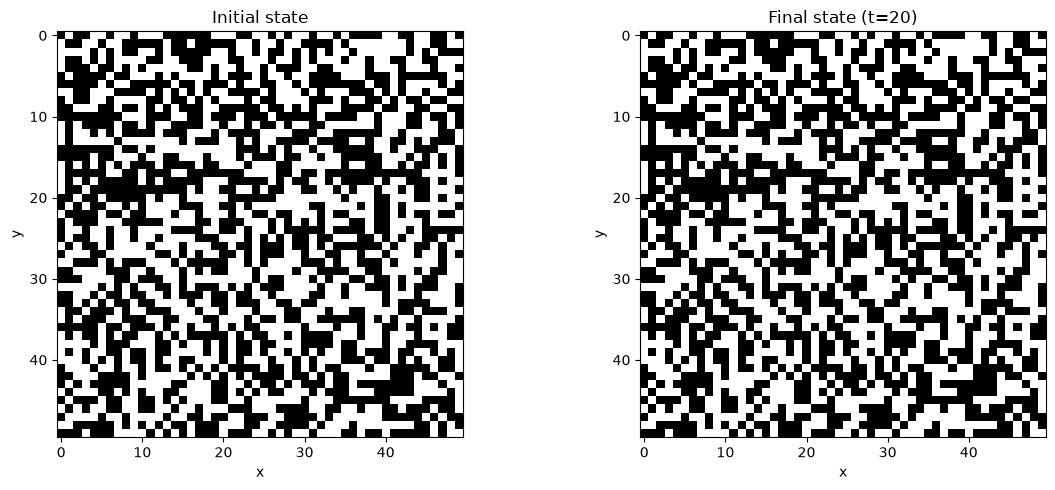

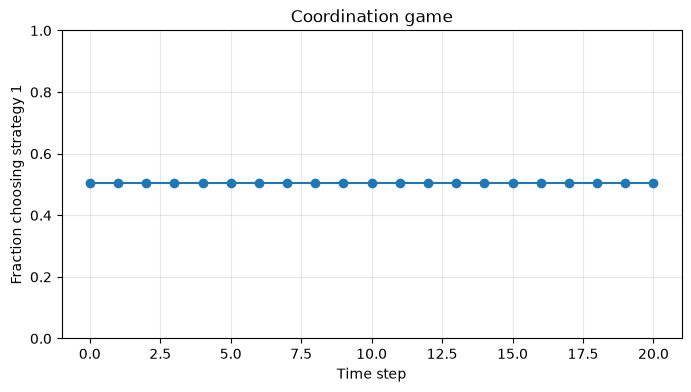

[np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036),
 np.float64(0.5036)]

In [32]:
run_simulation(grid)

In [33]:
grid = Grid(
    width=50,
    height=50,
    func=p_coordination,
    init_probs=0.5,
)

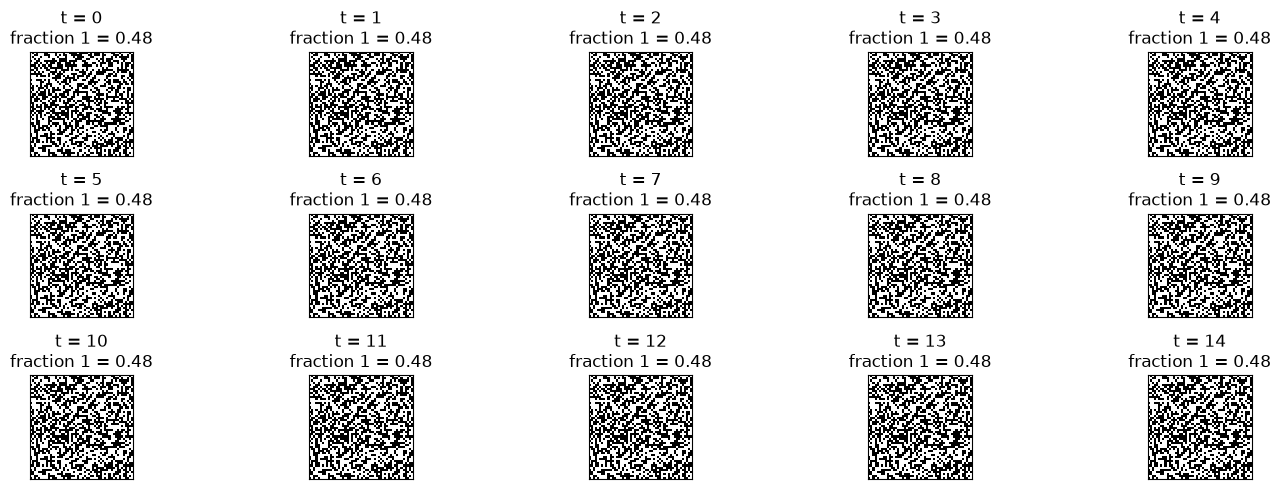

In [34]:
steps = 15

fig, axes = plt.subplots(
    3, 5,
    figsize=(15, 5)
)

axes = axes.flatten()

for t in range(steps):

    axes[t].imshow(
        grid.state_array(),
        cmap="binary",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    axes[t].set_title(
        f"t = {t}\n"
        f"fraction 1 = {grid.fraction_on():.2f}"
    )

    axes[t].set_xticks([])
    axes[t].set_yticks([])

    # Move to the next timestep
    if t < steps:
        grid.step()

# Hide unused plots
for ax in axes[steps + 1:]:
    ax.axis("off")

plt.tight_layout()
plt.show()